# What is the First Day of the Week?

Whether the Gregorian calendar shows Sunday or Monday as the first day of the week depends on where you live.

Do more countries start the week on Sunday or Monday? What about people? What about by continent?

The file `first-day-of-week.csv` shows the first day of the week for each territory. The file `population.csv` shows the population in the year 2020 for each territory in millions, and the file `four-regions.csv` specifies whether each territory is in asia, europe, africa, or the americas. 


In [27]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'first-day-of-week.csv', 'population.csv', and 'four-regions.csv'.

# from google.colab import files
# uploaded = files.upload()

In [28]:
import pandas as pd
df = pd.read_csv('first-day-of-week.csv')
df.head()

,territory,alpha3,first_day,units,paper
0,Afghanistan,AFG,sat,metric,A4
1,Aland Islands,ALA,mon,metric,A4
2,Albania,ALB,mon,metric,A4
3,Algeria,DZA,sat,metric,A4
4,American Samoa,ASM,sun,metric,A4


In [29]:
pop = pd.read_csv('population.csv')
pop.head()

,alpha3,population
0,AFG,39.07
1,ALB,2.87
2,DZA,44.04
3,AND,0.08
4,AGO,33.45


In [30]:
regions = pd.read_csv('four-regions.csv')
regions.head()

,alpha3,four_regions
0,AUS,asia
1,BRN,asia
2,KHM,asia
3,CHN,asia
4,FJI,asia


### Project Ideas

- How many territories show Friday, Saturday, Sunday, and Monday as the `first_day` of the week?

- How many people start the week on Friday, Saturday, Sunday, and Monday?
	- Hint: This will involve a `merge`.

- Which of the `four_regions` predominantly start the week on Sunday? On Monday? Are there any regions that are more divided between Sunday and Monday?
	- Hint: This will also involve a `merge`.

In [31]:
# YOUR CODE HERE (add additional cells as needed)

In [32]:
df['first_day'].value_counts()

first_day
mon    186
sun     55
sat     15
fri      1
Name: count, dtype: int64

<Axes: xlabel='first_day'>

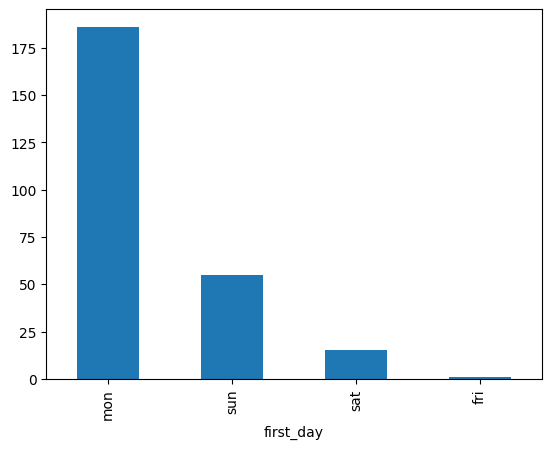

In [33]:
df["first_day"].value_counts().plot.bar()

In [44]:
merged = pd.merge(df, pop, on="alpha3")


In [46]:
people = merged.groupby(
    "first_day"
)["population"].sum()

print(people)


first_day
fri       0.50
mon    3600.19
sat     431.79
sun    3844.08
Name: population, dtype: float64


In [47]:
print(people)

first_day
fri       0.50
mon    3600.19
sat     431.79
sun    3844.08
Name: population, dtype: float64


<Axes: >

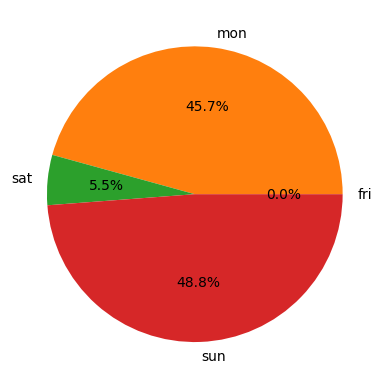

In [48]:
people.plot.pie(
    autopct="%1.1f%%"
)

In [51]:
filtered = merged[
    merged["first_day"].isin(
        ["Sunday", "Monday"]
    )
]

In [53]:
print(filtered.columns)

Index(['territory', 'alpha3', 'first_day', 'units', 'paper', 'population'], dtype='str')


In [55]:
counts = filtered.groupby(
    ["territory", "first_day"]
).size()

In [56]:
counts.unstack(fill_value=0)

first_day
territory


In [60]:
filtered = merged[
    merged["first_day"].isin(["Sun", "Mon"])]

In [63]:
merged = merged.merge(regions, on="alpha3")
filtered = merged[merged["first_day"].isin(["sun", "mon"])]
count = filtered.groupby(["four_regions", "first_day"]).size()
count

four_regions  first_day
africa        mon          43
              sun           6
americas      mon          15
              sun          20
asia          mon          27
              sun          21
europe        mon          46
              sun           2
dtype: int64

In [68]:
table = count.unstack(fill_value=0)
table["difference"] = abs(table["sun"] - table["mon"])


In [69]:
table.sort_values("difference")

first_day,mon,sun,difference
four_regions,,,
americas,15,20,5
asia,27,21,6
africa,43,6,37
europe,46,2,44


<Axes: xlabel='four_regions'>

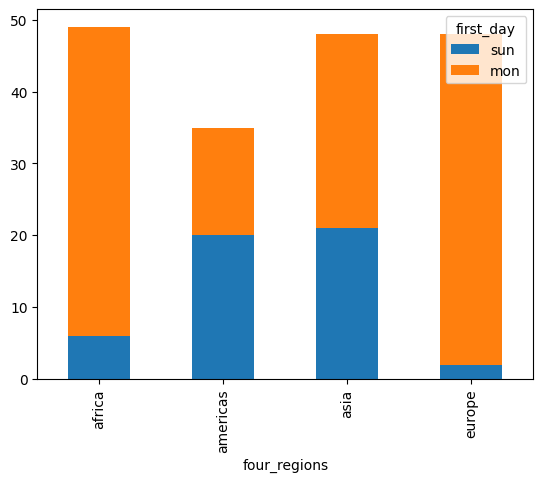

In [71]:
table[["sun", "mon"]].plot.bar(
    stacked=True
)

<Axes: xlabel='first_day', ylabel='four_regions'>

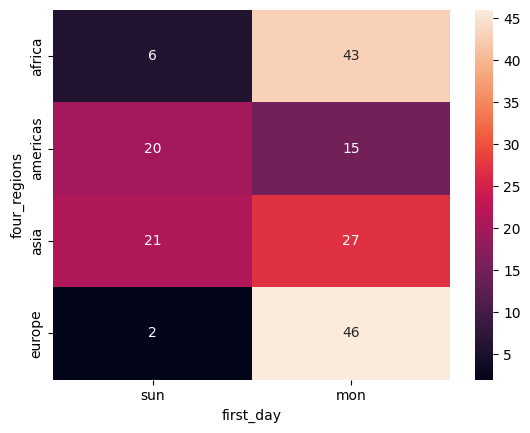

In [73]:
import seaborn as sns

sns.heatmap(
    table[["sun", "mon"]],
    annot=True
)